In [7]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model


base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(256,256,3)
)

base_model.trainable = False  # freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 256, 256,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 256, 256,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths and directories
PROJECT_ROOT = os.path.abspath('..')
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
IMAGE_DIR = os.path.join(DATA_DIR, "train-image", "image")
CSV_PATH = os.path.join(DATA_DIR, "train-metadata.csv")
MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Load and prepare dataframe
df = pd.read_csv(CSV_PATH)
df['target'] = df['target'].astype(str)
df['filename'] = df['isic_id'] + '.jpg'

# Train/validation split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['target'], random_state=42)

# Image data generators
train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.1, horizontal_flip=True)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(train_df, directory=IMAGE_DIR, x_col="filename", y_col="target", target_size=(256,256), batch_size=32, class_mode="binary")
val_data = val_gen.flow_from_dataframe(val_df, directory=IMAGE_DIR, x_col="filename", y_col="target", target_size=(256,256), batch_size=32, class_mode="binary")

# Callbacks and training
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "efficientnet_best.h5"),
        save_best_only=True
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=1,
    callbacks=callbacks
)

Found 26500 validated image filenames belonging to 2 classes.
Found 6626 validated image filenames belonging to 2 classes.


C:\Users\pkush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


829/829 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9762 - loss: 0.1101

829/829 ━━━━━━━━━━━━━━━━━━━━ 1043s 1s/step - accuracy: 0.9762 - loss: 0.1101 - val_accuracy: 0.9823 - val_loss: 0.0887


Found 6626 validated image filenames belonging to 2 classes.


C:\Users\pkush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


208/208 ━━━━━━━━━━━━━━━━━━━━ 146s 702ms/step
Classification report:
              precision    recall  f1-score   support

           0       0.99      0.71      0.83      6509
           1       0.03      0.44      0.05       117

    accuracy                           0.71      6626
   macro avg       0.51      0.57      0.44      6626
weighted avg       0.97      0.71      0.81      6626



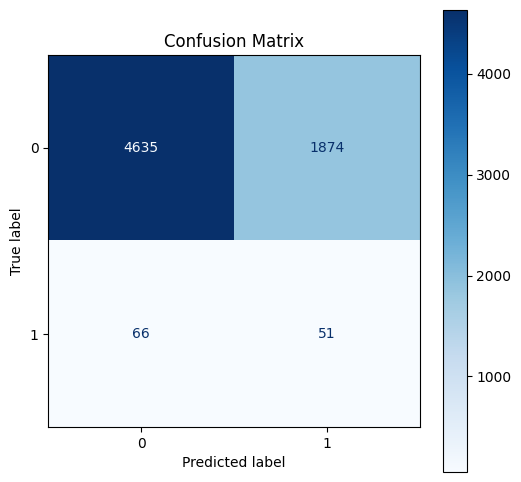

In [20]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

if 'model' in globals():
    m = model
elif os.path.exists(os.path.join(PROJECT_ROOT, 'models', 'efficientnet_best.h5')):
    m = load_model(os.path.join(PROJECT_ROOT, 'models', 'efficientnet_best.h5'))
elif os.path.exists('efficientnet_best.h5'):
    m = load_model('efficientnet_best.h5')
else:
    raise FileNotFoundError('No model found. Train a model or place `efficientnet_best.h5` in the models/ folder.')

pred_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_dataframe(
    val_df,
    directory=IMAGE_DIR,
    x_col='filename',
    y_col='target',
    target_size=(256, 256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
# Ensure we run prediction for all samples
steps = math.ceil(pred_gen.samples / pred_gen.batch_size)
preds = m.predict(pred_gen, steps=steps, verbose=1)
y_pred = (preds.ravel() >= 0.5).astype(int)
y_true = pred_gen.classes

label_map = {v: k for k, v in pred_gen.class_indices.items()}
target_names = [label_map[i] for i in sorted(label_map.keys())]

print('Classification report:')
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix and plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()


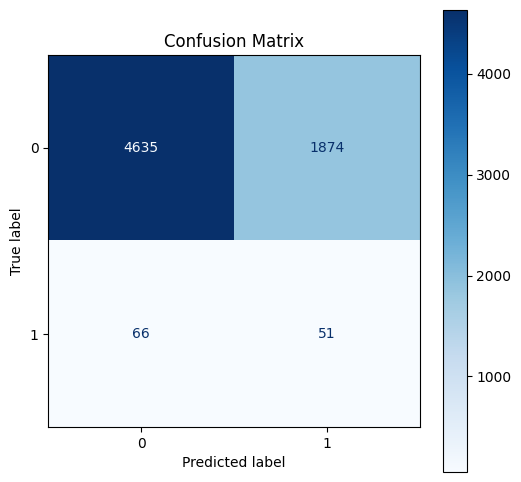

In [21]:
import pandas as pd
# Save classification report as CSV
rep = classification_report(y_true, y_pred, output_dict=True)
pd.DataFrame(rep).transpose().to_csv(os.path.join(MODEL_DIR, 'efficientnet_classification_report.csv'))

# Save confusion matrix plot
plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(MODEL_DIR, 'efficientnet_confusion_matrix.png'), bbox_inches='tight')
plt.show()